# Phase 4: Evaluation & Forecasting

**Objective:**
Final evaluation of the SARIMA models. In this separate notebook, we will:
1. Load the prepared daily data.
2. Initialize the specific SARIMA models defined in Phase 3.
3. Forecast the "hidden" test years (2005 and 2017).
4. Calculate accuracy metrics (MAE, RMSE, MAPE) and visually compare predictions.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
import os 

warnings.filterwarnings("ignore")
DAILY_FILE_ID = os.getenv("PJME_DAILY_FILE_ID")
HOURLY_FILE_ID = os.getenv("PJME_HOURLY_FILE_ID")

def load_from_gdrive(file_id):
    url = f"https://drive.google.com/uc?id={file_id}"
    return pd.read_csv(url, index_col= 0, parse_dates= True)

pjme_daily = load_from_gdrive(DAILY_FILE_ID)
pjme_daily.index.freq = 'D'


### 1. Model Initialization
We re-initialize the SARIMA models using the optimal parameters determined in Phase 3.
* **Early Era (Training: 2002-2004):** SARIMA(3, 0, 0)x(2, 0, 1, 7)
* **Late Era (Training: 2014-2016):** SARIMA(2, 0, 2)x(2, 0, 1, 7)

In [12]:
# 1. Early Era Model (2002-2004)
train_early = pjme_daily.loc['2002':'2004']['PJME']
model_early = SARIMAX(train_early, order=(3, 0, 0), seasonal_order=(2, 0, 1, 7))
results_early = model_early.fit(disp=False)

# 2. Late Era Model (2014-2016)
train_late = pjme_daily.loc['2014':'2016']['PJME']
model_late = SARIMAX(train_late, order=(2, 0, 2), seasonal_order=(2, 0, 1, 7))
results_late = model_late.fit(disp=False)

### 2. Forecasting & Metrics
We generate forecasts for the test years (2005 and 2017) and compare them against the actual observed values using three metrics:
* **MAE:** Mean Absolute Error (Average error in MW).
* **RMSE:** Root Mean Square Error (Penalizes large errors).
* **MAPE:** Mean Absolute Percentage Error (Relative accuracy).

In [13]:
# Forecast for test years
pred_2005 = results_early.predict(start='2005-01-01', end='2005-12-31')
pred_2017 = results_late.predict(start='2017-01-01', end='2017-12-31')

# Actual values
actual_2005 = pjme_daily.loc['2005']['PJME']
actual_2017 = pjme_daily.loc['2017']['PJME']

mae_05 = mean_absolute_error(actual_2005, pred_2005)
rmse_05 = np.sqrt(mean_squared_error(actual_2005, pred_2005))
mape_05 = np.mean(np.abs((actual_2005 - pred_2005) / actual_2005)) * 100

mae_17 = mean_absolute_error(actual_2017, pred_2017)
rmse_17 = np.sqrt(mean_squared_error(actual_2017, pred_2017))
mape_17 = np.mean(np.abs((actual_2017 - pred_2017) / actual_2017)) * 100

print("--- Results for Early Era (2005) ---")
print(f"MAE:  {mae_05:.2f}")
print(f"RMSE: {rmse_05:.2f}")
print(f"MAPE: {mape_05:.2f}%")
print("\n--- Results for Late Era (2017) ---")
print(f"MAE:  {mae_17:.2f}")
print(f"RMSE: {rmse_17:.2f}")
print(f"MAPE: {mape_17:.2f}%")

--- Results for Early Era (2005) ---
MAE:  4321.70
RMSE: 5712.71
MAPE: 11.91%

--- Results for Late Era (2017) ---
MAE:  3522.45
RMSE: 4440.06
MAPE: 11.10%


### 3. Visual Comparison
The plots below display the Actual Data (Blue) versus the Forecasted values (Red). This allows visual verification of whether the model captures the weekly seasonality and peak demands.

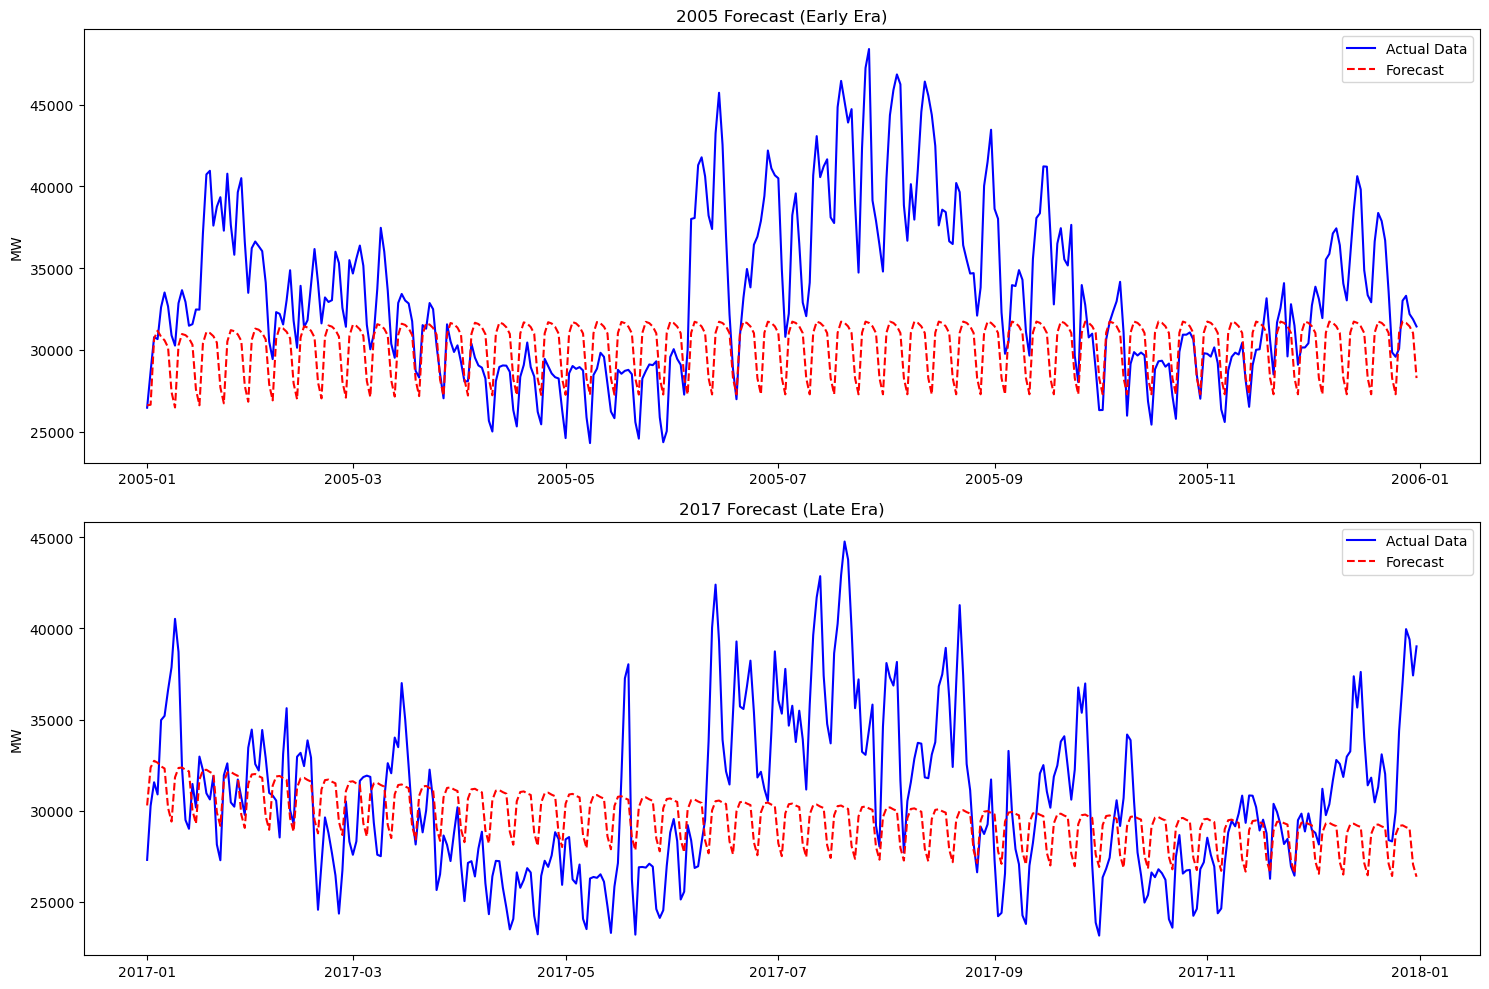

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Plot 2005
axes[0].plot(actual_2005.index, actual_2005, label='Actual Data', color='blue')
axes[0].plot(pred_2005.index, pred_2005, label='Forecast', color='red', linestyle='--')
axes[0].set_title('2005 Forecast (Early Era)')
axes[0].set_ylabel('MW')
axes[0].legend()

# Plot 2017
axes[1].plot(actual_2017.index, actual_2017, label='Actual Data', color='blue')
axes[1].plot(pred_2017.index, pred_2017, label='Forecast', color='red', linestyle='--')
axes[1].set_title('2017 Forecast (Late Era)')
axes[1].set_ylabel('MW')
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
# Create the Naive Forecast (Shift data by 7 days)
naive_forecast_2017 = pjme_daily.loc['2017', 'PJME'].shift(7).dropna()
actual_2017_aligned = pjme_daily.loc['2017', 'PJME'].iloc[7:] # Remove first 7 days to match

# Calculate the Error (MAPE) for the Naive Forecast
naive_mape_2017 = np.mean(np.abs((actual_2017_aligned - naive_forecast_2017) / actual_2017_aligned)) * 100

sarima_mape_2017 = mape_17
print("-" * 40)
print(f"2017 Model Evaluation")
print("-" * 40)
print(f"Naive Baseline MAPE: {naive_mape_2017:.2f}% (Benchmark)")
print(f"SARIMA Model MAPE:   {sarima_mape_2017:.2f}% (Probabilistic Model)")
print("-" * 40)

diff = sarima_mape_2017 - naive_mape_2017
print(diff)

----------------------------------------
2017 Model Evaluation
----------------------------------------
Naive Baseline MAPE: 10.36% (Benchmark)
SARIMA Model MAPE:   11.10% (Probabilistic Model)
----------------------------------------
0.7431896988942555


###  Final Evaluation & Conclusion

**1. Baseline Comparison**
We compared our SARIMA model against a "Naive Model" baseline (predicting next week = last week).
* **Naive MAPE:** 10.36%
* **SARIMA MAPE:** 11.10%

**2. Interpretation of Results**
Our model performs on par with the strong Naive baseline (within ~0.7%).
* **Insight:** This confirms that the 7-day weekly cycle is the primary driver of energy demand.
* **Value Add:** While the accuracy is similar, SARIMA is superior because it generates **Confidence Intervals**. A simple "naive guess" only gives a single number, whereas our model provides a safety range (Upper/Lower bounds) essential for risk management.

**3. Limitations & Future Improvements**
* **Human Habits and Energy Usage:** Energy consumption is heavily driven by rigid human schedules (9-to-5 workdays, weekends). Because "next Monday" almost always looks like "last Monday," the simple Naive model captures 90% of the signal instantly. This creates a "high floor" for accuracy that is mathematically difficult to beat.

* **Holiday Shocks:** The Naive model likely "won" slightly because it reacts instantly to recent levels, whereas SARIMA smooths them.
* **Whats the fix?:** To significantly beat the Naive baseline (e.g., get MAPE < 5%), obtaining **Temperature** data could be really beneficial, as weather is the only factor that disrupts the routine weekly schedule.